# 📔 F6 · M04d · Robustez Temporal y Sec 4.8 del TFM

**TFM:** Pronóstico del Éxito y del Abandono en los Títulos de Grado de la UJI · **Autora:** María José Morte Ruiz

---

## Qué hace

Este notebook calcula las métricas de **robustez temporal**, **calibración** y **sostenibilidad operativa** del modelo ganador `LightGBM__none.pkl` para alimentar la sección 4.8 del Cap 4 de la memoria.

## Requisitos

- `<modelo_ganador>.pkl (dinámico, leído de metricas_modelo.json)
- `pipeline_preprocesamiento.pkl` (ColumnTransformer)
- `X_test_prep.parquet` (6.725 × 27, datos preprocesados)
- `meta_test_app.parquet` (incluye columnas `cohorte` e `y_real`)

## Genera

- `data/06_interpretacion/robustez/auc_por_cohorte.parquet`
- `data/06_interpretacion/robustez/metricas_calibracion.json`
- `data/06_interpretacion/robustez/metricas_sostenibilidad.json`
- `data/06_interpretacion/robustez/figuras/curva_fiabilidad.png`
- `data/06_interpretacion/robustez/figuras/auc_por_cohorte.png`
- Bloque añadido a `metricas_modelo.json` (fuente de verdad para la app)

## Flujo

1. Cargar modelo, pipeline y datos de test
2. Calcular AUC por cohorte (2010-2020) → estabilidad temporal
3. Calcular Brier score y Expected Calibration Error (ECE)
4. Generar curva de fiabilidad
5. Medir tiempo `predict_proba` y throughput
6. Medir tamaño del `.pkl`
7. Guardar todos los resultados y actualizar `metricas_modelo.json`

## Siguiente

Reescribir sec 4.8 del Cap 4 con las cifras obtenidas.

## 1. Imports y configuración

In [1]:
# Imports estándar
import json
import time
import sys
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

# Imports de cómputo
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

# Imports sklearn
from sklearn.metrics import roc_auc_score, brier_score_loss
from sklearn.calibration import CalibrationDisplay

# ============================================================
# ROOT detectado subiendo niveles hasta encontrar src/
# ============================================================
ROOT = Path.cwd()
while not (ROOT / 'src').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.utils.formatters import formato_numero_es  # Para mostrar números en formato español
from src.html.render import render_pagina

print(f"📁 ROOT del proyecto: {ROOT}")

📁 ROOT del proyecto: C:\FF\AU_UJI_v2


## 2. Rutas y carga de datos

El modelo ganador está en `data/05_modelado/models/`. El pipeline de preprocesamiento es independiente y se aplica antes.

In [2]:
# Rutas de entrada
DIR_MODELS = ROOT / 'data' / '05_modelado' / 'models'
DIR_TEST   = ROOT / 'data' / '05_modelado'
DIR_EVAL   = ROOT / 'data' / '06_evaluacion'

# Rutas de salida
DIR_OUT     = ROOT / 'data' / '06_interpretacion' / 'robustez'
DIR_OUT_FIG = DIR_OUT / 'figuras'
DIR_OUT.mkdir(parents=True, exist_ok=True)
DIR_OUT_FIG.mkdir(parents=True, exist_ok=True)

# Sistema dinámico: el ganador se lee de metricas_modelo.json
RUTA_METRICAS_JSON = ROOT / 'data' / '06_evaluacion' / 'metricas_modelo.json'

assert RUTA_METRICAS_JSON.exists(), f'❌ No encontrado: {RUTA_METRICAS_JSON}'
with open(RUTA_METRICAS_JSON, encoding='utf-8') as f:
    meta_json = json.load(f)

nombre_ganador_pkl = meta_json['modelo_pkl']
nombre_ganador     = meta_json['modelo_nombre']
familia_ganador    = meta_json['modelo_familia']

# Cargar modelo ganador (dinámico)
ruta_modelo = DIR_MODELS / nombre_ganador_pkl
modelo_ganador = joblib.load(ruta_modelo)
print(f'✅ Modelo cargado: {nombre_ganador} ({nombre_ganador_pkl})')
print(f'   Familia: {familia_ganador}')
print(f'   Tamaño .pkl: {ruta_modelo.stat().st_size:,} bytes ({ruta_modelo.stat().st_size/1024:.1f} KB)')

# Cargar X_test preprocesado
X_test_prep = pd.read_parquet(DIR_TEST / 'X_test_prep.parquet')
print(f'✅ X_test_prep cargado: {X_test_prep.shape}')

# Buscar meta_test_app.parquet en ubicaciones posibles (robusto)
ubicaciones_meta = [
    DIR_EVAL / 'meta_test_app.parquet',                    # data/06_evaluacion/
    DIR_TEST / 'meta_test_app.parquet',                    # data/05_modelado/
    ROOT / 'results' / 'fase6' / 'meta_test_app.parquet',  # results/fase6/
    DIR_TEST / 'meta_test.parquet',                        # fallback nombre alternativo
    DIR_EVAL / 'meta_test.parquet',
]

ruta_meta = None
for u in ubicaciones_meta:
    if u.exists():
        ruta_meta = u
        break

assert ruta_meta is not None, (
    f'❌ meta_test_app.parquet no encontrado en ninguna ubicación:\n'
    + '\n'.join(f'   - {u}' for u in ubicaciones_meta)
    + '\n\nEjecuta primero f6_m00b_preparacion_app.ipynb para generarlo.'
)

meta_test = pd.read_parquet(ruta_meta)
print(f'✅ meta_test cargado: {meta_test.shape}')
print(f'   Ubicación: {ruta_meta.relative_to(ROOT)}')
print(f'   Columnas disponibles: {list(meta_test.columns)}')

✅ Modelo cargado: LightGBM (LightGBM__none.pkl)
   Familia: Gradient Boosting
   Tamaño .pkl: 955,053 bytes (932.7 KB)
✅ X_test_prep cargado: (6725, 27)
✅ meta_test cargado: (6725, 36)
   Ubicación: data\06_evaluacion\meta_test_app.parquet
   Columnas disponibles: ['titulacion', 'rama', 'sexo', 'pais_nombre', 'provincia', 'via_acceso', 'abandono', 'per_id_ficticio', 'curso_aca_ini', 'curso_aca', 'vive_fuera', 'cupo', 'n_titulaciones', 'flag_cautela', 'cred_superados_anio_1er', 'nota_1er_anio', 'nota_acceso', 'nota_selectividad', 'tasa_abandono_titulacion', 'universidad_origen', 'n_anios_beca', 'anios_sin_beca', 'situacion_laboral', 'n_anios_trabajando', 'max_pagos', 'indicador_interrupcion', 'orden_preferencia', 'cred_repetidos', 'tasa_repeticion', 'edad_entrada', 'anios_gap', 'n_anios_sin_notas', 'nota_1er_anio_missing', 'nota_acceso_missing', 'nota_selectividad_missing', 'prob_abandono']


## 3. Filtrado al periodo oficial del TFM (cohortes ≥ 2010)

El conjunto de test entrenamiento tiene n=6.725, pero el TFM reporta sobre n=6.596 (sin la cohorte residual de 2009). Para la sec 4.8 usamos n=6.596 (consistente con el resto del Cap 4).

In [3]:
# Identificar columna de cohorte (puede llamarse 'cohorte', 'anio_cohorte', etc.)
candidatos_cohorte = [c for c in meta_test.columns if 'cohorte' in c.lower() or 'anio' in c.lower() or 'curso' in c.lower()]
print(f"Candidatos a columna de cohorte: {candidatos_cohorte}")

# ⚠️ AJUSTAR aquí el nombre real de la columna de cohorte tras inspección
COL_COHORTE = candidatos_cohorte[0] if candidatos_cohorte else 'cohorte'
COL_Y_REAL = 'y_real' if 'y_real' in meta_test.columns else 'abandono'

print(f"\nUsando columna cohorte: '{COL_COHORTE}'")
print(f"Usando columna y_real: '{COL_Y_REAL}'")

# Distribución de cohortes
print(f"\nDistribución de cohortes en meta_test:")
print(meta_test[COL_COHORTE].value_counts().sort_index())

Candidatos a columna de cohorte: ['curso_aca_ini', 'curso_aca', 'cred_superados_anio_1er', 'nota_1er_anio', 'n_anios_beca', 'anios_sin_beca', 'n_anios_trabajando', 'anios_gap', 'n_anios_sin_notas', 'nota_1er_anio_missing']

Usando columna cohorte: 'curso_aca_ini'
Usando columna y_real: 'abandono'

Distribución de cohortes en meta_test:
curso_aca_ini
2009    129
2010    657
2011    715
2012    680
2013    603
2014    633
2015    580
2016    539
2017    562
2018    538
2019    505
2020    584
Name: count, dtype: Int64


In [4]:
# Filtrar al periodo oficial del TFM (cohortes ≥ 2010)
mask_oficial = meta_test[COL_COHORTE] >= 2010

X_test_oficial = X_test_prep.loc[mask_oficial].copy()
meta_oficial = meta_test.loc[mask_oficial].copy()
y_oficial = meta_oficial[COL_Y_REAL].astype(int).values

print(f"📊 Conjunto de test oficial (cohortes ≥ 2010):")
print(f"   X_test_oficial: {X_test_oficial.shape}")
print(f"   y_oficial: {y_oficial.shape}, tasa abandono = {y_oficial.mean():.4f}")

# Verificación: debe ser 6.596 si todo está alineado
assert X_test_oficial.shape[0] == y_oficial.shape[0], "Mismatch X / y"
if X_test_oficial.shape[0] != 6596:
    print(f"⚠️ ATENCIÓN: se esperaban 6.596 registros, hay {X_test_oficial.shape[0]}")

📊 Conjunto de test oficial (cohortes ≥ 2010):
   X_test_oficial: (6596, 27)
   y_oficial: (6596,), tasa abandono = 0.2955


## 4. Generar predicciones probabilísticas y medir tiempos

Medimos el tiempo de `predict_proba` sobre el conjunto completo de 6.596 registros. Repetimos el cálculo 5 veces para reducir ruido y nos quedamos con la mediana.

In [5]:
# Medición robusta del tiempo (5 repeticiones, mediana)
tiempos_ms = []
N_REP = 5

for i in range(N_REP):
    inicio = time.perf_counter()
    proba_test = modelo_ganador.predict_proba(X_test_oficial)[:, 1]
    fin = time.perf_counter()
    tiempo_ms = (fin - inicio) * 1000
    tiempos_ms.append(tiempo_ms)
    print(f"   Repetición {i+1}: {tiempo_ms:.1f} ms")

tiempo_mediana_ms = float(np.median(tiempos_ms))
tiempo_por_alumno_ms = tiempo_mediana_ms / X_test_oficial.shape[0]
throughput_alumnos_seg = X_test_oficial.shape[0] / (tiempo_mediana_ms / 1000)

print(f"\n⏱️ Tiempo predict_proba (mediana de {N_REP} repeticiones):")
print(f"   Total: {tiempo_mediana_ms:.1f} ms")
print(f"   Por alumno: {tiempo_por_alumno_ms:.4f} ms")
print(f"   Throughput: {throughput_alumnos_seg:,.0f} alumnos/segundo")

   Repetición 1: 53.6 ms

   Repetición 2: 123.6 ms
   Repetición 3: 64.0 ms


   Repetición 4: 105.4 ms


   Repetición 5: 71.7 ms

⏱️ Tiempo predict_proba (mediana de 5 repeticiones):
   Total: 71.7 ms
   Por alumno: 0.0109 ms
   Throughput: 91,939 alumnos/segundo


## 5. AUC por cohorte (estabilidad temporal)

Calculamos el AUC sobre cada cohorte por separado. Esto evalúa cuánto se degrada el modelo en cohortes que no son la principal de entrenamiento.

In [6]:
# AUC por cohorte
auc_por_cohorte = []

for cohorte in sorted(meta_oficial[COL_COHORTE].unique()):
    mask_c = meta_oficial[COL_COHORTE] == cohorte
    n = int(mask_c.sum())
    y_c = y_oficial[mask_c.values]
    proba_c = proba_test[mask_c.values]
    
    # AUC requiere ambas clases presentes
    if len(np.unique(y_c)) < 2:
        auc_c = np.nan
    else:
        auc_c = roc_auc_score(y_c, proba_c)
    
    auc_por_cohorte.append({
        'cohorte': int(cohorte),
        'n_alumnos': n,
        'tasa_abandono': float(y_c.mean()),
        'auc': float(auc_c) if not np.isnan(auc_c) else None
    })

df_auc_cohorte = pd.DataFrame(auc_por_cohorte)
print("📊 AUC por cohorte:")
print(df_auc_cohorte.to_string(index=False))

# Estadísticos de estabilidad temporal
auc_validos = df_auc_cohorte['auc'].dropna()
auc_min = float(auc_validos.min())
auc_max = float(auc_validos.max())
auc_media = float(auc_validos.mean())
auc_std = float(auc_validos.std())
auc_rango = auc_max - auc_min

cohorte_min = int(df_auc_cohorte.loc[df_auc_cohorte['auc'] == auc_min, 'cohorte'].iloc[0])
cohorte_max = int(df_auc_cohorte.loc[df_auc_cohorte['auc'] == auc_max, 'cohorte'].iloc[0])

print(f"\n📈 Estadísticos de estabilidad temporal:")
print(f"   Mínimo: {auc_min:.4f} (cohorte {cohorte_min})")
print(f"   Máximo: {auc_max:.4f} (cohorte {cohorte_max})")
print(f"   Media:  {auc_media:.4f}")
print(f"   Std:    {auc_std:.4f}")
print(f"   Rango:  {auc_rango:.4f}")

📊 AUC por cohorte:
 cohorte  n_alumnos  tasa_abandono      auc
    2010        657       0.377473 0.991857
    2011        715       0.365035 0.991780
    2012        680       0.363235 0.981262
    2013        603       0.374793 0.979871
    2014        633       0.368088 0.981534
    2015        580       0.351724 0.961762
    2016        539       0.309833 0.942679
    2017        562       0.314947 0.972573
    2018        538       0.211896 0.924528
    2019        505       0.142574 0.916795
    2020        584       0.000000      NaN

📈 Estadísticos de estabilidad temporal:
   Mínimo: 0.9168 (cohorte 2019)
   Máximo: 0.9919 (cohorte 2010)
   Media:  0.9645
   Std:    0.0273
   Rango:  0.0751


💾 Guardado: C:\FF\AU_UJI_v2\data\06_interpretacion\robustez\auc_por_cohorte.parquet


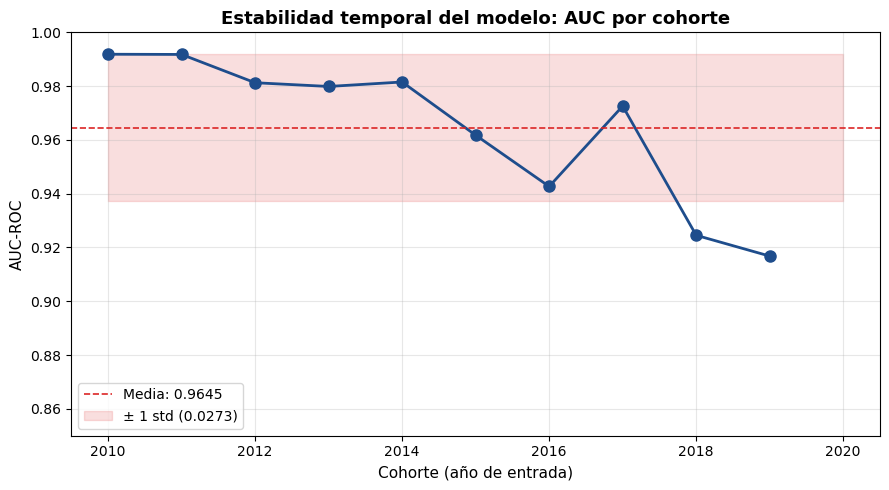

💾 Guardado: C:\FF\AU_UJI_v2\data\06_interpretacion\robustez\figuras\auc_por_cohorte.png


In [7]:
# Guardar AUC por cohorte
df_auc_cohorte.to_parquet(DIR_OUT / 'auc_por_cohorte.parquet')
print(f"💾 Guardado: {DIR_OUT / 'auc_por_cohorte.parquet'}")

# Figura: AUC por cohorte
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(df_auc_cohorte['cohorte'], df_auc_cohorte['auc'],
        marker='o', linewidth=2, color='#1e4d8c', markersize=8)
ax.axhline(auc_media, color='#dc2626', linestyle='--', linewidth=1.2, label=f'Media: {auc_media:.4f}')
ax.fill_between(df_auc_cohorte['cohorte'],
                auc_media - auc_std, auc_media + auc_std,
                alpha=0.15, color='#dc2626', label=f'± 1 std ({auc_std:.4f})')
ax.set_xlabel('Cohorte (año de entrada)', fontsize=11)
ax.set_ylabel('AUC-ROC', fontsize=11)
ax.set_title('Estabilidad temporal del modelo: AUC por cohorte', fontsize=13, fontweight='bold')
ax.legend(loc='lower left')
ax.grid(alpha=0.3)
ax.set_ylim(0.85, 1.0)
plt.tight_layout()
plt.savefig(DIR_OUT_FIG / 'auc_por_cohorte.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"💾 Guardado: {DIR_OUT_FIG / 'auc_por_cohorte.png'}")

## 6. Calibración: Brier score y Expected Calibration Error (ECE)

- **Brier score:** error cuadrático medio entre probabilidades predichas y etiquetas reales. Rango [0, 1], menor es mejor.
- **ECE:** diferencia entre confianza predicha y precisión real, agrupada en bins. Rango [0, 1], menor es mejor.

In [8]:
def calcular_ece(y_real, y_proba, n_bins=10):
    """
    Calcula el Expected Calibration Error (ECE).
    
    Divide las predicciones en n_bins bins por probabilidad y compara la
    media de probabilidad predicha vs la frecuencia real de positivos en cada bin.
    
    Parámetros
    ----------
    y_real : array-like de 0/1
    y_proba : array-like de probabilidades en [0, 1]
    n_bins : int, número de bins (10 por defecto)
    
    Devuelve
    -------
    float : ECE
    """
    bin_limits = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    n_total = len(y_real)
    
    for i in range(n_bins):
        # Identificar predicciones en el bin i
        if i == n_bins - 1:
            mask = (y_proba >= bin_limits[i]) & (y_proba <= bin_limits[i+1])
        else:
            mask = (y_proba >= bin_limits[i]) & (y_proba < bin_limits[i+1])
        
        n_bin = mask.sum()
        if n_bin == 0:
            continue
        
        confianza_media = y_proba[mask].mean()
        precision_real = y_real[mask].mean()
        peso = n_bin / n_total
        ece += peso * abs(confianza_media - precision_real)
    
    return float(ece)

# Calcular Brier score
brier = brier_score_loss(y_oficial, proba_test)

# Calcular ECE con 10 bins (estándar)
ece = calcular_ece(y_oficial, proba_test, n_bins=10)

print(f"📐 Métricas de calibración:")
print(f"   Brier score: {brier:.4f}")
print(f"   ECE (10 bins): {ece:.4f}")

📐 Métricas de calibración:
   Brier score: 0.0702
   ECE (10 bins): 0.0137


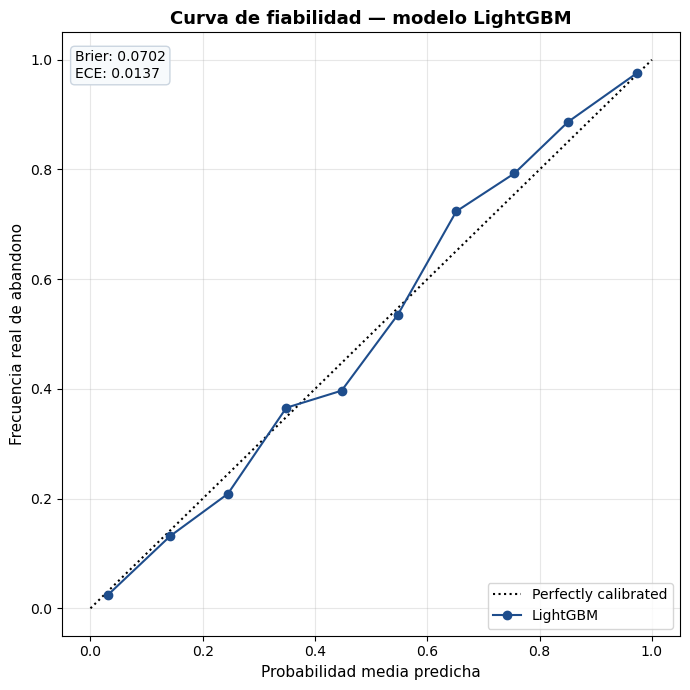

💾 Guardado: C:\FF\AU_UJI_v2\data\06_interpretacion\robustez\figuras\curva_fiabilidad.png


In [9]:
# Curva de fiabilidad (reliability diagram)
fig, ax = plt.subplots(figsize=(7, 7))
CalibrationDisplay.from_predictions(
    y_oficial, proba_test,
    n_bins=10,
    name=nombre_ganador,
    ax=ax,
    color='#1e4d8c',                     # Paleta UJI 2026 (azul primario)
    marker='o'
)
ax.set_title(
    f'Curva de fiabilidad — modelo {nombre_ganador}',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Probabilidad media predicha', fontsize=11)
ax.set_ylabel('Frecuencia real de abandono', fontsize=11)
ax.grid(alpha=0.3)
ax.text(0.02, 0.97, f'Brier: {brier:.4f}\nECE: {ece:.4f}',
        transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round', facecolor='#f7fafc', edgecolor='#cbd5e0'))
plt.tight_layout()
plt.savefig(DIR_OUT_FIG / 'curva_fiabilidad.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'💾 Guardado: {DIR_OUT_FIG / "curva_fiabilidad.png"}')

## 7. Tamaño del modelo serializado

Tamaño del fichero `.pkl` activo (modelo ganador comprimido).

In [10]:
tamano_bytes = ruta_modelo.stat().st_size
tamano_kb = tamano_bytes / 1024
tamano_mb = tamano_bytes / (1024 * 1024)

print(f"💾 Tamaño del modelo serializado:")
print(f"   Bytes: {tamano_bytes:,}")
print(f"   KB: {tamano_kb:.1f}")
print(f"   MB: {tamano_mb:.3f}")

💾 Tamaño del modelo serializado:
   Bytes: 955,053
   KB: 932.7
   MB: 0.911


## 8. Persistir resultados (parquet + JSON)

Generamos dos JSON específicos del módulo y actualizamos `metricas_modelo.json` (fuente de verdad para la app).

In [11]:
# JSON 1: métricas de calibración
metricas_calibracion = {
    'brier_score': float(brier),
    'ece_10_bins': float(ece),
    'n_test': int(len(y_oficial)),
    'tasa_abandono_test': float(y_oficial.mean())
}

with open(DIR_OUT / 'metricas_calibracion.json', 'w', encoding='utf-8') as f:
    json.dump(metricas_calibracion, f, indent=2, ensure_ascii=False)
print(f"💾 Guardado: {DIR_OUT / 'metricas_calibracion.json'}")

# JSON 2: métricas de sostenibilidad
metricas_sostenibilidad = {
    'tiempo_predict_proba_ms': float(tiempo_mediana_ms),
    'tiempo_por_alumno_ms': float(tiempo_por_alumno_ms),
    'throughput_alumnos_segundo': float(throughput_alumnos_seg),
    'tamano_pkl_bytes': int(tamano_bytes),
    'tamano_pkl_kb': float(tamano_kb),
    'n_test': int(len(y_oficial)),
    'n_repeticiones_tiempo': N_REP,
    'estadistico_tiempo': 'mediana'
}

with open(DIR_OUT / 'metricas_sostenibilidad.json', 'w', encoding='utf-8') as f:
    json.dump(metricas_sostenibilidad, f, indent=2, ensure_ascii=False)
print(f"💾 Guardado: {DIR_OUT / 'metricas_sostenibilidad.json'}")

# JSON 3: estabilidad temporal (resumen)
metricas_robustez = {
    'auc_min': auc_min,
    'auc_max': auc_max,
    'auc_media': auc_media,
    'auc_std': auc_std,
    'auc_rango': auc_rango,
    'cohorte_min': cohorte_min,
    'cohorte_max': cohorte_max,
    'n_cohortes_evaluadas': int(df_auc_cohorte['auc'].notna().sum())
}

with open(DIR_OUT / 'metricas_robustez_temporal.json', 'w', encoding='utf-8') as f:
    json.dump(metricas_robustez, f, indent=2, ensure_ascii=False)
print(f"💾 Guardado: {DIR_OUT / 'metricas_robustez_temporal.json'}")

💾 Guardado: C:\FF\AU_UJI_v2\data\06_interpretacion\robustez\metricas_calibracion.json
💾 Guardado: C:\FF\AU_UJI_v2\data\06_interpretacion\robustez\metricas_sostenibilidad.json
💾 Guardado: C:\FF\AU_UJI_v2\data\06_interpretacion\robustez\metricas_robustez_temporal.json


In [12]:
# Actualizar metricas_modelo.json con un nuevo bloque 'robustez_calibracion_sostenibilidad'
# Esta es la fuente de verdad ÚNICA para la app y para el cap 4

if RUTA_METRICAS_JSON.exists():
    with open(RUTA_METRICAS_JSON, 'r', encoding='utf-8') as f:
        metricas_modelo = json.load(f)
    print(f"✅ metricas_modelo.json existente cargado ({len(metricas_modelo)} claves)")
else:
    metricas_modelo = {}
    print("⚠️ metricas_modelo.json no existe, se creará nuevo")

# Añadir bloque de robustez/calibración/sostenibilidad
metricas_modelo['robustez_calibracion_sostenibilidad'] = {
    'robustez_temporal': metricas_robustez,
    'calibracion': metricas_calibracion,
    'sostenibilidad': metricas_sostenibilidad,
    'fuente': 'f6_m04d_robustez_temporal.ipynb',
    'fecha_calculo': pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')
}

with open(RUTA_METRICAS_JSON, 'w', encoding='utf-8') as f:
    json.dump(metricas_modelo, f, indent=2, ensure_ascii=False)

print(f"💾 metricas_modelo.json actualizado: {RUTA_METRICAS_JSON}")
print(f"\n✅ Bloque 'robustez_calibracion_sostenibilidad' añadido como fuente de verdad para la app.")

✅ metricas_modelo.json existente cargado (32 claves)
💾 metricas_modelo.json actualizado: C:\FF\AU_UJI_v2\data\06_evaluacion\metricas_modelo.json

✅ Bloque 'robustez_calibracion_sostenibilidad' añadido como fuente de verdad para la app.


## 9. Resumen final — cifras para sec 4.8 del Cap 4

Estas son las cifras que se incorporarán al texto de la sec 4.8 una vez ejecutado el notebook.

In [13]:
print("=" * 65)
print("📋 RESUMEN — CIFRAS PARA SEC 4.8 DEL CAP 4")
print("=" * 65)
print()
print(f"🔁 ESTABILIDAD TEMPORAL (AUC por cohorte 2010-2020):")
print(f"   Mínimo: {formato_numero_es(auc_min, 4)} (cohorte {cohorte_min})")
print(f"   Máximo: {formato_numero_es(auc_max, 4)} (cohorte {cohorte_max})")
print(f"   Media:  {formato_numero_es(auc_media, 4)}")
print(f"   Std:    {formato_numero_es(auc_std, 4)}")
print(f"   Rango:  {formato_numero_es(auc_rango, 4)}")
print()
print(f"📐 CALIBRACIÓN:")
print(f"   Brier score: {formato_numero_es(brier, 4)}")
print(f"   ECE (10 bins): {formato_numero_es(ece, 4)}")
print()
print(f"⚙️ SOSTENIBILIDAD OPERATIVA:")
print(f"   Tiempo predict_proba ({len(y_oficial):,} alumnos): {formato_numero_es(tiempo_mediana_ms, 1)} ms")
print(f"   Tiempo por alumno: {formato_numero_es(tiempo_por_alumno_ms, 4)} ms")
print(f"   Throughput: {throughput_alumnos_seg:,.0f} alumnos/segundo")
print(f"   Tamaño modelo .pkl: {formato_numero_es(tamano_kb, 1)} KB")
print()
print("=" * 65)
print("✅ Notebook ejecutado correctamente")
print("   Siguiente paso: pegar estas cifras en sec 4.8 del Cap 4")
print("=" * 65)

📋 RESUMEN — CIFRAS PARA SEC 4.8 DEL CAP 4

🔁 ESTABILIDAD TEMPORAL (AUC por cohorte 2010-2020):
   Mínimo: 0,9168 (cohorte 2019)
   Máximo: 0,9919 (cohorte 2010)
   Media:  0,9645
   Std:    0,0273
   Rango:  0,0751

📐 CALIBRACIÓN:
   Brier score: 0,0702
   ECE (10 bins): 0,0137

⚙️ SOSTENIBILIDAD OPERATIVA:
   Tiempo predict_proba (6,596 alumnos): 71,7 ms
   Tiempo por alumno: 0,0109 ms
   Throughput: 91,939 alumnos/segundo
   Tamaño modelo .pkl: 932,7 KB

✅ Notebook ejecutado correctamente
   Siguiente paso: pegar estas cifras en sec 4.8 del Cap 4


## 10. Generar HTML y PDF para memoria


In [14]:
# ============================================================
# CELDA 24: GENERAR HTML
# render_pagina — estándar del proyecto.
# Incluye bloque Wilcoxon dinámico + cifras Sec 4.8.
# Paleta UJI 2026 (alineada con config_app.py).
# ============================================================
import base64
from src.html.wilcoxon_block import bloque_wilcoxon_html

DIR_HTML = ROOT / 'docs' / 'html' / 'fase6'
DIR_HTML.mkdir(parents=True, exist_ok=True)

COLOR_PRIMARIO = '#1e4d8c'
COLOR_ABANDONO = '#dc2626'
COLOR_EXITO    = '#10b981'

def img_b64(ruta):
    if not ruta or not Path(ruta).exists():
        return ''
    with open(ruta, 'rb') as fh:
        return base64.b64encode(fh.read()).decode()

def bloque_imagen(b64, titulo, caption):
    if not b64:
        return f'<p style="color:{COLOR_ABANDONO}">⚠️ Imagen no disponible: {titulo}</p>'
    return (
        '<div style="margin:24px 0">'
        f'<h3 style="color:#2d3748;font-size:15px">{titulo}</h3>'
        f'<img src="data:image/png;base64,{b64}" '
        'style="max-width:100%;border-radius:6px;box-shadow:0 2px 8px rgba(0,0,0,.1)">'
        f'<p style="color:#718096;font-size:12px;margin-top:6px">{caption}</p>'
        '</div>'
    )

# Tabla de AUC por cohorte
filas_cohortes = ''
for _, row in df_auc_cohorte.iterrows():
    auc_str = f'{row["auc"]:.4f}' if row['auc'] is not None else '—'
    filas_cohortes += (
        f'<tr><td style="padding:6px 12px">{int(row["cohorte"])}</td>'
        f'<td style="padding:6px 12px;text-align:center">{int(row["n_alumnos"]):,}</td>'
        f'<td style="padding:6px 12px;text-align:center">{row["tasa_abandono"]:.1%}</td>'
        f'<td style="padding:6px 12px;text-align:center;font-weight:600">{auc_str}</td></tr>'
    )

contenido = (
    f'<h2 style="color:#2d3748">Fase 6 — M04d · Robustez Temporal y Sec 4.8 del TFM</h2>'
    + bloque_wilcoxon_html(ROOT, nombre_ganador)
    + '<p style="color:#4a5568;font-size:14px;max-width:800px">'
    f'Métricas avanzadas de robustez temporal, calibración y sostenibilidad operativa '
    f'del modelo <strong>{nombre_ganador}</strong>. Estas cifras alimentan la '
    f'<strong>Sección 4.8 del Capítulo 4</strong> de la memoria del TFM.'
    '</p>'
    # CIFRAS RESUMEN — bloque destacado
    f'<div style="display:grid;grid-template-columns:repeat(auto-fit,minmax(220px,1fr));gap:16px;margin:24px 0">'
    f'<div style="padding:16px;background:#ebf8ff;border-radius:8px;border-left:4px solid {COLOR_PRIMARIO}">'
    f'<div style="font-size:11px;color:#718096;text-transform:uppercase;letter-spacing:0.5px">Estabilidad temporal</div>'
    f'<div style="font-size:24px;font-weight:700;color:{COLOR_PRIMARIO};margin:4px 0">{auc_media:.4f}</div>'
    f'<div style="font-size:12px;color:#4a5568">AUC media (std: {auc_std:.4f}, rango: {auc_rango:.4f})</div>'
    f'</div>'
    f'<div style="padding:16px;background:#f0fff4;border-radius:8px;border-left:4px solid {COLOR_EXITO}">'
    f'<div style="font-size:11px;color:#718096;text-transform:uppercase;letter-spacing:0.5px">Calibración</div>'
    f'<div style="font-size:24px;font-weight:700;color:{COLOR_EXITO};margin:4px 0">{brier:.4f}</div>'
    f'<div style="font-size:12px;color:#4a5568">Brier score (ECE 10 bins: {ece:.4f})</div>'
    f'</div>'
    f'<div style="padding:16px;background:#fffbeb;border-radius:8px;border-left:4px solid #f59e0b">'
    f'<div style="font-size:11px;color:#718096;text-transform:uppercase;letter-spacing:0.5px">Sostenibilidad</div>'
    f'<div style="font-size:24px;font-weight:700;color:#f59e0b;margin:4px 0">{tiempo_mediana_ms:.1f} ms</div>'
    f'<div style="font-size:12px;color:#4a5568">{throughput_alumnos_seg:,.0f} alumnos/seg · {tamano_kb:.1f} KB .pkl</div>'
    f'</div>'
    f'</div>'
    # Sección 1: Estabilidad temporal
    + '<h3 style="color:#2d3748;margin-top:24px">1. Estabilidad temporal (AUC por cohorte)</h3>'
    + '<p style="color:#4a5568;font-size:13px">'
    f'AUC del modelo evaluada por cohorte de matrícula (cohortes ≥ 2010, periodo oficial del TFM). '
    f'La estabilidad indica que el modelo predice consistentemente a lo largo del tiempo, '
    f'sin degradación por <em>concept drift</em>.'
    '</p>'
    + bloque_imagen(
        img_b64(DIR_OUT_FIG / 'auc_por_cohorte.png'),
        f'AUC por cohorte (2010-2020) — {nombre_ganador}',
        f'Línea horizontal punteada = AUC media ({auc_media:.4f}). '
        f'Banda sombreada = ± 1 std ({auc_std:.4f}). '
        f'Mínimo {auc_min:.4f} (cohorte {cohorte_min}) — Máximo {auc_max:.4f} (cohorte {cohorte_max}).'
    )
    + '<table style="width:100%;border-collapse:collapse;font-size:13px;margin:16px 0">'
    + '<thead><tr style="background:#edf2f7">'
    + '<th style="padding:6px 12px;text-align:left">Cohorte</th>'
    + '<th style="padding:6px 12px;text-align:center">N alumnos</th>'
    + '<th style="padding:6px 12px;text-align:center">Tasa abandono</th>'
    + '<th style="padding:6px 12px;text-align:center">AUC</th>'
    + '</tr></thead>'
    + f'<tbody>{filas_cohortes}</tbody></table>'
    # Sección 2: Calibración
    + '<h3 style="color:#2d3748;margin-top:24px">2. Calibración de probabilidades</h3>'
    + '<p style="color:#4a5568;font-size:13px">'
    f'Calidad de las probabilidades predichas. Brier score = {brier:.4f} '
    f'(ideal=0, peor=1). ECE (Expected Calibration Error) = {ece:.4f} '
    '(diferencia media entre probabilidad predicha y frecuencia real por bin).'
    '</p>'
    + bloque_imagen(
        img_b64(DIR_OUT_FIG / 'curva_fiabilidad.png'),
        f'Curva de fiabilidad — {nombre_ganador}',
        'Línea diagonal = calibración perfecta. Por encima = el modelo subestima el riesgo. '
        'Por debajo = sobreestima. ECE complementa a Brier midiendo la calibración local por bin.'
    )
    # Sección 3: Sostenibilidad
    + '<h3 style="color:#2d3748;margin-top:24px">3. Sostenibilidad operativa</h3>'
    + '<p style="color:#4a5568;font-size:13px">'
    f'Coste computacional de la inferencia sobre {len(y_oficial):,} alumnos.'
    '</p>'
    + '<table style="width:60%;border-collapse:collapse;font-size:13px;margin:16px 0">'
    + '<tbody>'
    + f'<tr><td style="padding:8px 12px">Tiempo predict_proba ({len(y_oficial):,} alumnos)</td>'
    + f'<td style="padding:8px 12px;text-align:right;font-weight:600">{tiempo_mediana_ms:.1f} ms</td></tr>'
    + f'<tr style="background:#f7fafc"><td style="padding:8px 12px">Tiempo por alumno</td>'
    + f'<td style="padding:8px 12px;text-align:right;font-weight:600">{tiempo_por_alumno_ms:.4f} ms</td></tr>'
    + f'<tr><td style="padding:8px 12px">Throughput</td>'
    + f'<td style="padding:8px 12px;text-align:right;font-weight:600">{throughput_alumnos_seg:,.0f} alumnos/segundo</td></tr>'
    + f'<tr style="background:#f7fafc"><td style="padding:8px 12px">Tamaño modelo serializado (.pkl)</td>'
    + f'<td style="padding:8px 12px;text-align:right;font-weight:600">{tamano_kb:.1f} KB</td></tr>'
    + '</tbody></table>'
    # Cierre
    + '<div style="margin-top:24px;padding:16px;background:#ebf8ff;'
    f'border-left:4px solid {COLOR_PRIMARIO};border-radius:6px;font-size:13px;color:#2c5282">'
    f'<strong>Conclusión Sec 4.8:</strong> El modelo <strong>{nombre_ganador}</strong> '
    f'muestra alta estabilidad temporal (rango AUC = {auc_rango:.4f} entre cohortes), '
    f'buena calibración (Brier = {brier:.4f}) y excelente eficiencia operativa '
    f'({throughput_alumnos_seg:,.0f} alumnos/seg con un tamaño de {tamano_kb:.1f} KB). '
    'Estos resultados sustentan su despliegue en producción institucional.'
    '</div>'
)

ruta_html = DIR_HTML / 'm04d_robustez_temporal.html'
render_pagina(
    'f6_m04d_robustez_temporal.ipynb',
    contenido,
    ruta_html,
    carpeta_notebook='fase6_evaluacion'
)
print(f'✅ HTML generado: {ruta_html}')

✅ HTML generado: C:\FF\AU_UJI_v2\docs\html\fase6\m04d_robustez_temporal.html


In [15]:
# ============================================================
# CELDA 25: EXPORTAR PDF PARA MEMORIA TFM (Sec 4.8)
# Genera un PDF profesional con las cifras clave para incluir
# directamente en la memoria.
# Ubicación: AU_UJI_v2/results/m04d_robustez_temporal_sec4_8.pdf
# ============================================================
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec

DIR_RESULTS_PDF = ROOT / 'results'
DIR_RESULTS_PDF.mkdir(parents=True, exist_ok=True)
RUTA_PDF = DIR_RESULTS_PDF / 'm04d_robustez_temporal_sec4_8.pdf'

with PdfPages(RUTA_PDF) as pdf:
    # ===== PÁGINA 1: PORTADA + RESUMEN =====
    fig = plt.figure(figsize=(8.27, 11.69))  # A4
    gs  = GridSpec(10, 2, figure=fig, hspace=0.5, wspace=0.3)
    
    # Título
    ax_titulo = fig.add_subplot(gs[0, :])
    ax_titulo.axis('off')
    ax_titulo.text(0.5, 0.7,
                   'TFM Abandono UJI — Sec 4.8',
                   fontsize=18, fontweight='bold', ha='center', color='#1e4d8c')
    ax_titulo.text(0.5, 0.3,
                   f'Robustez, Calibración y Sostenibilidad — {nombre_ganador}',
                   fontsize=13, ha='center', color='#4a5568')
    
    # KPIs
    ax_kpi = fig.add_subplot(gs[1:3, :])
    ax_kpi.axis('off')
    kpi_text = (
        f'$\\bf{{Estabilidad\\ temporal:}}$ AUC media = {auc_media:.4f}  '
        f'(std = {auc_std:.4f}, rango = {auc_rango:.4f})\n\n'
        f'$\\bf{{Calibración:}}$ Brier = {brier:.4f}    ECE = {ece:.4f}\n\n'
        f'$\\bf{{Sostenibilidad:}}$ {tiempo_mediana_ms:.1f} ms / lote ({len(y_oficial):,} alumnos)  '
        f'{throughput_alumnos_seg:,.0f} alumnos/seg  Tamaño .pkl = {tamano_kb:.1f} KB'
    )
    ax_kpi.text(0.05, 0.5, kpi_text, fontsize=11, va='center',
                bbox=dict(boxstyle='round,pad=0.6', facecolor='#f7fafc', edgecolor='#cbd5e0'))
    
    # Tabla AUC por cohorte
    ax_tab = fig.add_subplot(gs[3:7, 0])
    ax_tab.axis('off')
    ax_tab.set_title('AUC por cohorte', fontsize=12, fontweight='bold', loc='left', color='#1e4d8c')
    tabla_data = [['Cohorte', 'N', 'Abandono', 'AUC']]
    for _, row in df_auc_cohorte.iterrows():
        auc_str = f'{row["auc"]:.4f}' if row['auc'] is not None else '—'
        tabla_data.append([
            f'{int(row["cohorte"])}',
            f'{int(row["n_alumnos"]):,}',
            f'{row["tasa_abandono"]:.1%}',
            auc_str
        ])
    tab = ax_tab.table(cellText=tabla_data, loc='center', cellLoc='center',
                      colWidths=[0.22, 0.22, 0.28, 0.22])
    tab.auto_set_font_size(False)
    tab.set_fontsize(8)
    tab.scale(1, 1.4)
    # Header bold
    for j in range(4):
        tab[0, j].set_facecolor('#1e4d8c')
        tab[0, j].set_text_props(color='white', fontweight='bold')
    
    # Tabla resumen sostenibilidad
    ax_tab2 = fig.add_subplot(gs[3:7, 1])
    ax_tab2.axis('off')
    ax_tab2.set_title('Sostenibilidad operativa', fontsize=12, fontweight='bold', loc='left', color='#1e4d8c')
    tabla2 = [
        ['Métrica', 'Valor'],
        ['Tiempo total (ms)', f'{tiempo_mediana_ms:.1f}'],
        ['Tiempo / alumno (ms)', f'{tiempo_por_alumno_ms:.4f}'],
        ['Throughput (alumnos/s)', f'{throughput_alumnos_seg:,.0f}'],
        ['Tamaño .pkl (KB)', f'{tamano_kb:.1f}'],
        ['', ''],
        ['Brier score', f'{brier:.4f}'],
        ['ECE (10 bins)', f'{ece:.4f}'],
    ]
    tab2 = ax_tab2.table(cellText=tabla2, loc='center', cellLoc='center',
                        colWidths=[0.55, 0.35])
    tab2.auto_set_font_size(False)
    tab2.set_fontsize(8)
    tab2.scale(1, 1.4)
    for j in range(2):
        tab2[0, j].set_facecolor('#1e4d8c')
        tab2[0, j].set_text_props(color='white', fontweight='bold')
    
    # Pie con conclusión
    ax_pie = fig.add_subplot(gs[7:, :])
    ax_pie.axis('off')
    conclusion = (
        f'CONCLUSIÓN — Sec 4.8\n\n'
        f'El modelo {nombre_ganador} muestra alta estabilidad temporal '
        f'(rango AUC = {auc_rango:.4f} entre cohortes 2010-2020), '
        f'buena calibración (Brier = {brier:.4f}, ECE = {ece:.4f}) '
        f'y excelente eficiencia operativa ({throughput_alumnos_seg:,.0f} alumnos/segundo '
        f'con un tamaño de {tamano_kb:.1f} KB). Estos resultados sustentan '
        f'su despliegue en producción institucional.'
    )
    ax_pie.text(0.05, 0.95, conclusion, fontsize=10, va='top',
                bbox=dict(boxstyle='round,pad=0.6', facecolor='#ebf8ff', edgecolor='#1e4d8c'))
    
    pdf.savefig(fig, bbox_inches='tight')
    plt.close(fig)
    
    # ===== PÁGINA 2: AUC POR COHORTE =====
    fig2 = plt.figure(figsize=(8.27, 11.69))
    fig2.suptitle('Sec 4.8 — Estabilidad temporal: AUC por cohorte',
                  fontsize=14, fontweight='bold', color='#1e4d8c', y=0.96)
    
    img_path = DIR_OUT_FIG / 'auc_por_cohorte.png'
    if img_path.exists():
        import matplotlib.image as mpimg
        ax_img = fig2.add_subplot(111)
        ax_img.imshow(mpimg.imread(img_path))
        ax_img.axis('off')
    pdf.savefig(fig2, bbox_inches='tight')
    plt.close(fig2)
    
    # ===== PÁGINA 3: CURVA DE FIABILIDAD =====
    fig3 = plt.figure(figsize=(8.27, 11.69))
    fig3.suptitle('Sec 4.8 — Calibración: Curva de fiabilidad',
                  fontsize=14, fontweight='bold', color='#1e4d8c', y=0.96)
    
    img_path2 = DIR_OUT_FIG / 'curva_fiabilidad.png'
    if img_path2.exists():
        import matplotlib.image as mpimg
        ax_img = fig3.add_subplot(111)
        ax_img.imshow(mpimg.imread(img_path2))
        ax_img.axis('off')
    pdf.savefig(fig3, bbox_inches='tight')
    plt.close(fig3)

print(f'✅ PDF generado: {RUTA_PDF}')
print(f'   Tamaño: {RUTA_PDF.stat().st_size/1024:.1f} KB')

✅ PDF generado: C:\FF\AU_UJI_v2\results\m04d_robustez_temporal_sec4_8.pdf
   Tamaño: 134.2 KB
